<a href="https://colab.research.google.com/github/darshanukande07/-EE-machine-learning-/blob/main/EE_p10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np

In [3]:
class Layer:
    def __init__(self):
        self.input = None
        self.output = None

    def forward(self, input):
        pass

    def backward(self,output_gradient, learning_rate):
        pass

In [4]:
class Dense(Layer):
    def __init__(self, input_size, output_size):
        self.weights = np.random.randn(output_size, input_size)
        self.bias = np.random.randn(output_size, 1)

    def forward(self, input):
        self.input = input
        return np.dot(self.weights, self.input) + self.bias

    def backward(self, output_gradient, input_gradient):
        weights_gradient = np.dot(output_gradient, self.input.T)
        input_gradient = np.dot(self.weights.T, output_gradient)

        self.weights -= learning_rate * weights_gradient
        self.bias -= learning_rate * output_gradient

        return input_gradient

In [15]:
def mse(y_true, y_pred):
    return np.mean(np.power(y_true - y_pred, 2))

def mse_prime(y_true, y_pred):
    return 2 * (y_pred - y_true) / np.size(y_true)

In [5]:
class Activation(Layer):
    def __init__(self, activation, activation_prime):
        self.activation = activation
        self.activation_prime = activation_prime

    def forward(self, input):
        self.input = input
        return self.activation(self.input)

    def backward(self, output_gradient, learning_rate):
        return np.multiply(output_gradient, self.activation_prime(self.input))

In [6]:
class Tanh(Activation):
    def __init__(self):
        def tanh(x):
            return np.tanh(x)

        def tanh_prime(x):
            return 1- np.tanh(x) ** 2

        super().__init__(tanh, tanh_prime)


class Sigmoid(Activation):
    def __init__(self):
        def sigmoid(x):
            return 1 / (1 + np.exp(-x))

        def sigmoid_prime(x):
            s = sigmoid(x)
            return s * (1-s)

        super().__init__(sigmoid, sigmoid_prime)

In [12]:
import math

In [13]:
class Linear(Activation):
    def __init__(self):
        def linear(x):
            return x

        def linear_prime(x):
            return 1

        super().__init__(linear, linear_prime)

In [16]:
X = np.linspace(-3,3,61)
Y = [math.sin(p) for p in X]

network = [
    Dense(1, 10),
    Tanh(),
    Dense(10, 1),
    Linear()
]

epochs = 50
learning_rate = 0.1
errorlist = []

for e in range(epochs):
    error = 0
    for x,y in zip(X,Y):
        output = x
        for layer in network:
            output=layer.forward(output)
        error += mse(y,output)
        grad = mse_prime(y,output)

        for layer in reversed(network):
            grad = layer.backward(grad, learning_rate)
    error /= len(X)
    print(f"{e + 1}/({epochs}, error={error}")
    errorlist.append(error)

1/(50, error=719410.9356646885
2/(50, error=8357556049703.331
3/(50, error=3.948596903336545e+19
4/(50, error=1.931486038887012e+26
5/(50, error=9.541841590953115e+32
6/(50, error=4.713673659125555e+39
7/(50, error=2.3285570707603554e+46
8/(50, error=1.1503083199029113e+53
9/(50, error=5.6825286674706145e+59
10/(50, error=2.8071719119053106e+66
11/(50, error=1.3867442830689135e+73
12/(50, error=6.850523469790154e+79
13/(50, error=3.384161909525899e+86
14/(50, error=1.671777621139489e+93
15/(50, error=8.258589539335431e+99
16/(50, error=4.079747229343344e+106
17/(50, error=2.0153971057718948e+113
18/(50, error=9.956071456435565e+119
19/(50, error=4.9183041179215834e+126
20/(50, error=2.4296446145661394e+133
21/(50, error=1.2002456154713925e+140
22/(50, error=5.929219149260364e+146
23/(50, error=2.9290371293003236e+153
24/(50, error=1.446945759441188e+160
25/(50, error=7.147919054426522e+166
26/(50, error=3.531075472266905e+173
27/(50, error=1.7443529922353423e+180
28/(50, error=8.617112

/tmp/ipykernel_1325/430305362.py:21: RuntimeWarning: overflow encountered in scalar add
  error += mse(y,output)
/tmp/ipykernel_1325/2117857837.py:2: RuntimeWarning: overflow encountered in power
  return np.mean(np.power(y_true - y_pred, 2))
/tmp/ipykernel_1325/494197032.py:11: RuntimeWarning: invalid value encountered in multiply
  return np.multiply(output_gradient, self.activation_prime(self.input))


In [19]:
actual_Y = []
for x in X:
    output = x
    for layer in network:
        output=layer.forward(output)
    actual_Y.append(output[0])
    print(output)

[[nan]]
[[nan]]
[[nan]]
[[nan]]
[[nan]]
[[nan]]
[[nan]]
[[nan]]
[[nan]]
[[nan]]
[[nan]]
[[nan]]
[[nan]]
[[nan]]
[[nan]]
[[nan]]
[[nan]]
[[nan]]
[[nan]]
[[nan]]
[[nan]]
[[nan]]
[[nan]]
[[nan]]
[[nan]]
[[nan]]
[[nan]]
[[nan]]
[[nan]]
[[nan]]
[[nan]]
[[nan]]
[[nan]]
[[nan]]
[[nan]]
[[nan]]
[[nan]]
[[nan]]
[[nan]]
[[nan]]
[[nan]]
[[nan]]
[[nan]]
[[nan]]
[[nan]]
[[nan]]
[[nan]]
[[nan]]
[[nan]]
[[nan]]
[[nan]]
[[nan]]
[[nan]]
[[nan]]
[[nan]]
[[nan]]
[[nan]]
[[nan]]
[[nan]]
[[nan]]
[[nan]]


In [20]:
import matplotlib.pyplot as plt

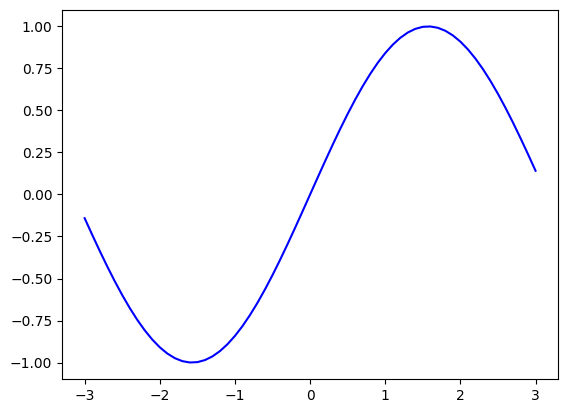

In [21]:
plt.plot(X,Y,color='blue')
plt.plot(X, actual_Y,color='red')
plt.show()

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

In [26]:
def preprocess_data(x, y, limit):
        x = x.reshape(x.shape[0], 28 * 28, 1)
        x = x.astype("float32")/255

        y = to_categorical(y)
        y = y.reshape(y.shape[0], 10, 1)

        return x[:limit], y[:limit]

In [27]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train, y_train = preprocess_data(x_train, y_train, 10000)
x_test, y_test = preprocess_data(x_test, y_test, 20)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [34]:
network = [
    Dense(784, 80),
    Sigmoid(),
    Dense(80, 10),
    Sigmoid()
]

epochs = 50
learning_rate = 0.1
errorlist = []

for e in range(epochs):
    error = 0
    for x,y in zip(x_train,y_train):
        output = x
        for layer in network:
            output=layer.forward(output)
        error += mse(y,output)
        grad = mse_prime(y,output)

        for layer in reversed(network):
            grad = layer.backward(grad, learning_rate)
    error /= len(x)
    print(f"{e + 1}/({epochs}, error={error}")
    errorlist.append(error)

1/(50, error=1.3241483342242986
2/(50, error=1.1733890242497504
3/(50, error=1.018669777508973
4/(50, error=0.8509646632631723
5/(50, error=0.7291511955080827
6/(50, error=0.6425674674215872
7/(50, error=0.5935985583045921
8/(50, error=0.5603596669208001
9/(50, error=0.5057787325589647
10/(50, error=0.428470510803705
11/(50, error=0.40254794711868885
12/(50, error=0.38527673705928883
13/(50, error=0.3717254955660963
14/(50, error=0.3604896772922641
15/(50, error=0.35082566558688777
16/(50, error=0.3423141782696338
17/(50, error=0.33467357050073465
18/(50, error=0.327681444602035
19/(50, error=0.3211606086608401
20/(50, error=0.31501119168747344
21/(50, error=0.3092147289666033
22/(50, error=0.303842183781693
23/(50, error=0.29890386999405966
24/(50, error=0.294336911278501
25/(50, error=0.2900670465168513
26/(50, error=0.28603441169656024
27/(50, error=0.28219447790329116
28/(50, error=0.2785165555621612
29/(50, error=0.27498731563036116
30/(50, error=0.27161436070482725
31/(50, error=

In [36]:
def predict(network, input):
    output = input
    for layer in network:
        output = layer.forward(output)
    return output

In [50]:
!pip install simple-colors

In [52]:
import simple_colors

In [53]:
correct = 0

for x,y in zip(x_test, y_test):
    output = predict(network ,x)
    if np.argmax(output) == np.argmax(y):
        correct += 1
        print('pred:', np.argmax(output), '\ttrue:', np.argmax(y))
    else:
        print(simple_colors.red(f'pred: {np.argmax(output)} \ttrue: {np.argmax(y)}'))

accuracy = correct / len(y_test)
print(f"Accuracy: {accuracy}")
print(f"Correct: {correct}")

pred: 7 	true: 7
pred: 2 	true: 2
pred: 1 	true: 1
pred: 0 	true: 0
pred: 4 	true: 4
pred: 1 	true: 1
pred: 4 	true: 4
pred: 9 	true: 9
pred: 6 	true: 5
pred: 9 	true: 9
pred: 0 	true: 0
pred: 6 	true: 6
pred: 9 	true: 9
pred: 0 	true: 0
pred: 1 	true: 1
pred: 5 	true: 5
pred: 9 	true: 9
pred: 7 	true: 7
pred: 6 	true: 3
pred: 4 	true: 4
Accuracy: 0.9
Correct: 18


In [54]:
error = errorlist
X = list(range(1,len(errorlist) + 1))

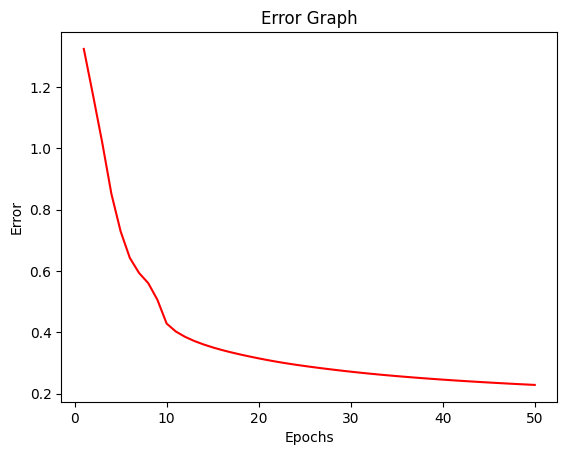

In [55]:
plt.plot(X, error, color='r')
plt.xlabel("Epochs")
plt.ylabel("Error")
plt.title("Error Graph")
plt.show()